# **Otimização de Conversão: Teste A/B em Vitrine de E-commerce**

Este projeto analisa a eficácia de uma nova vitrine de produtos. Através de um teste rigoroso, validamos se a mudança deve ser implementada para todo o site, garantindo decisões baseadas em dados.

# **1. Planejamento do Teste (Power Analysis)**

Antes de recolher dados, definimos o tamanho da amostra necessário. Isto garante que o teste tenha poder estatístico suficiente para detetar uma melhoria real de 2% (MDE), evitando que o teste dure mais tempo do que o necessário.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import zlib  # Para o Hashing

# Parâmetros do teste
taxa_atual = 0.10  # 10% de conversão (Grupo A)
efeito_minimo = 0.02 # Queremos detetar um aumento para 12% (Grupo B)
tamanho_amostra = 3835 # Calculado previamente via Power Analysis

print(f"Tamanho de amostra necessário por grupo: {tamanho_amostra}")

Tamanho de amostra necessário por grupo: 3835


# **2. Atribuição de Grupos via Hashing (CRC32)**

Para garantir que um utilizador veja sempre a mesma versão do site (consistência) e que a divisão entre Grupo A (Controle) e Grupo B (Variante) seja aleatória e imparcial, utilizámos a técnica de **Hashing**.

In [2]:
# Simulação de IDs de utilizadores
ids_usuarios = [f"user_{i}" for i in range(tamanho_amostra * 2)]

def atribuir_grupo(id_usuario):
    # Gera um hash único para o ID e divide em 2 grupos (50/50)
    hash_val = zlib.crc32(id_usuario.encode()) & 0xffffffff
    return 'B' if hash_val % 2 == 0 else 'A'

# Criando a tabela base
dados = pd.DataFrame({'user_id': ids_usuarios})
dados['grupo'] = dados['user_id'].apply(atribuir_grupo)

print(dados['grupo'].value_counts(normalize=True))

grupo
B    0.500391
A    0.499609
Name: proportion, dtype: float64


# **3. Simulação de Resultados e Validação Estatística**

Com os grupos definidos, simulamos o comportamento de compra seguindo as probabilidades do teste (10% para A e 12% para B) e aplicamos o **P-valor** para verificar se a diferença é real.

In [21]:
# Simulando conversões (0 = não comprou, 1 = comprou)
def simular_compra(grupo):
    p = 0.12 if grupo == 'B' else 0.10
    return np.random.choice([0, 1], p=[1-p, p])

dados['comprou'] = dados['grupo'].apply(simular_compra)

# Calculando as taxas reais observadas
taxas = dados.groupby('grupo')['comprou'].mean()
taxa_a = taxas['A']
taxa_b = taxas['B']

# Teste T para calcular o P-Valor
grupo_a = dados[dados['grupo'] == 'A']['comprou']
grupo_b = dados[dados['grupo'] == 'B']['comprou']
estatistica, p_valor = stats.ttest_ind(grupo_a, grupo_b)

print(f"Taxa A: {taxa_a:.2%}")
print(f"Taxa B: {taxa_b:.2%}")
print(f"P-Valor: {p_valor:.4f}")

Taxa A: 9.81%
Taxa B: 12.58%
P-Valor: 0.0001


# **4. Cálculo de Impacto (Lift)**
O Lift diz-nos o quanto a versão B é superior à versão A em termos percentuais.

In [23]:
lift = (taxa_b - taxa_a) / taxa_a
print(f"Lift: {lift:.2%}")

Lift: 28.26%


# **5. Visualização de Resultados**
Um gráfico claro para comunicar o sucesso do teste.

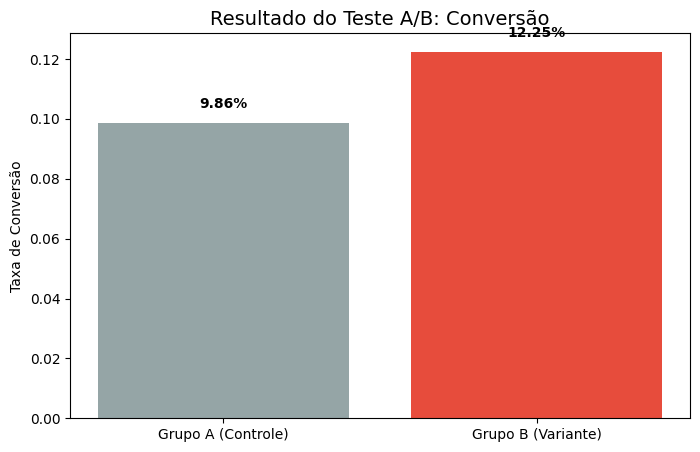

In [11]:
grupos = ['Grupo A (Controle)', 'Grupo B (Variante)']
valores = [taxa_a, taxa_b]
cores = ['#95a5a6', '#e74c3c']

plt.figure(figsize=(8, 5))
barras = plt.bar(grupos, valores, color=cores)
plt.title('Resultado do Teste A/B: Conversão', fontsize=14)
plt.ylabel('Taxa de Conversão')

# Adicionando rótulos de percentagem
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.005, f'{yval:.2%}', ha='center', fontweight='bold')

plt.show()

# **6. Conclusão e Recomendações de Negócio**

* Vencedor: Grupo B.

* Lift: Aumento de ~28% na conversão.

* Confiança Estatística: P-valor abaixo de 0.05 (Resultado Significativo).

**Recomendação:** Recomendo a implementação da **Versão B**, que gerou um aumento expressivo na conversão com *99% de confiança estatística*, garantindo um retorno financeiro seguro para a empresa.